In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6122.41it/s]


Ready!


In [2]:
text = "The cat sat on the"
inputs = tokenizer(text, return_tensors="pt")

# Normal output
with torch.no_grad():
    normal_out = model(**inputs)
normal_probs = torch.softmax(normal_out.logits[0, -1, :], dim=0)
print(f"Normal top word: '{tokenizer.decode([normal_probs.argmax()])}'")

# Layer 5 
layer_idx = 5
all_acts  = []

def capture_hook(module, input, output):
    all_acts.append(output.detach().clone())

hook = model.transformer.h[layer_idx].mlp.act.register_forward_hook(
    capture_hook)

with torch.no_grad():
    model(**inputs)

hook.remove()

neuron_acts = all_acts[0][0]  # [n_tokens, 3072]
median_vals = neuron_acts.median(dim=0).values  # [3072]

print(f"Neuron activations shape: {neuron_acts.shape}")
print(f"Median values shape: {median_vals.shape}")


kl_scores = []

for neuron_idx in range(0, 3072, 10):  
    def replace_hook(module, input, output):
        modified = output.clone()
        modified[:, :, neuron_idx] = median_vals[neuron_idx]
        return modified
    
    hook = model.transformer.h[layer_idx].mlp.act.register_forward_hook(
        replace_hook)
    
    with torch.no_grad():
        replaced_out = model(**inputs)
    
    hook.remove()
    
    replaced_probs = torch.softmax(
        replaced_out.logits[0, -1, :], dim=0)
    
    kl = F.kl_div(
        torch.log(replaced_probs + 1e-10),
        normal_probs + 1e-10,
        reduction='sum'
    ).item()
    
    kl_scores.append((neuron_idx, kl))

top10 = sorted(kl_scores, key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 most important neurons (Layer {layer_idx}):")
for neuron, kl in top10:
    print(f"  Neuron {neuron:<6}: KL = {kl:.4f}")

Normal top word: ' floor'
Neuron activations shape: torch.Size([5, 3072])
Median values shape: torch.Size([3072])

Top 10 most important neurons (Layer 5):
  Neuron 1870  : KL = 0.0017
  Neuron 1490  : KL = 0.0006
  Neuron 2870  : KL = 0.0005
  Neuron 3020  : KL = 0.0004
  Neuron 10    : KL = 0.0001
  Neuron 2070  : KL = 0.0001
  Neuron 1790  : KL = 0.0001
  Neuron 2450  : KL = 0.0001
  Neuron 1020  : KL = 0.0001
  Neuron 280   : KL = 0.0001


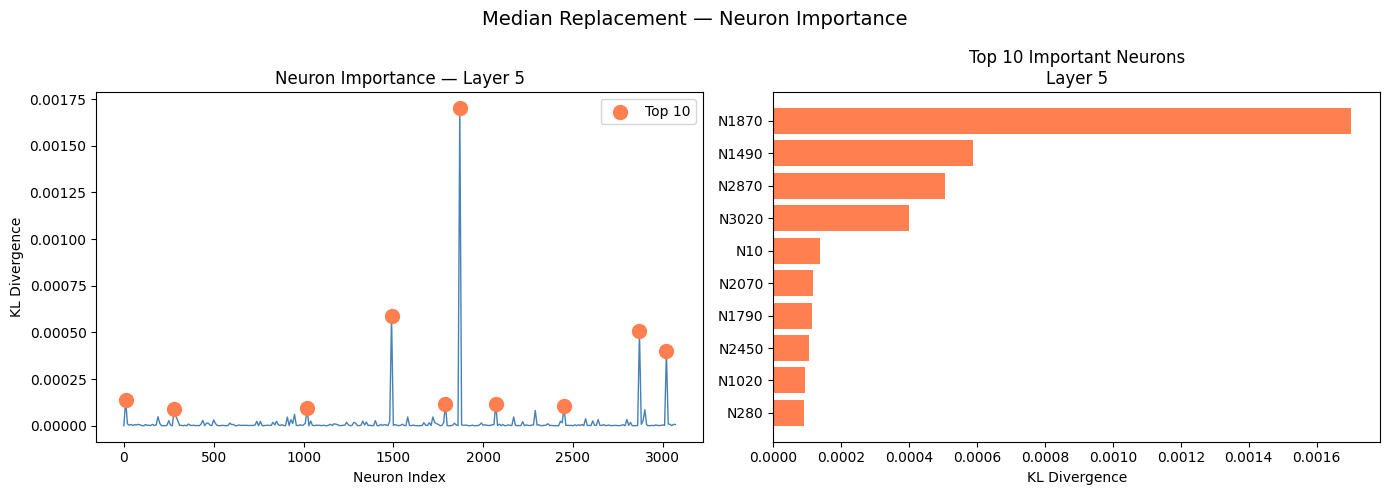

In [3]:
neurons, kls = zip(*kl_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(neurons, kls, color="steelblue", linewidth=1)
axes[0].set_xlabel("Neuron Index")
axes[0].set_ylabel("KL Divergence")
axes[0].set_title(f"Neuron Importance — Layer {layer_idx}")

top10_neurons = [n for n, k in top10]
top10_kls     = [k for n, k in top10]
axes[0].scatter(top10_neurons, top10_kls, 
                color="coral", s=100, zorder=5,
                label="Top 10")
axes[0].legend()

axes[1].barh([f"N{n}" for n, k in top10[::-1]],
             [k for n, k in top10[::-1]],
             color="coral")
axes[1].set_xlabel("KL Divergence")
axes[1].set_title(f"Top 10 Important Neurons\nLayer {layer_idx}")

plt.suptitle("Median Replacement — Neuron Importance", fontsize=14)
plt.tight_layout()
plt.show()

* Neuron 1870 in Layer 5 is the most important.
* KL values are very small — there is a lot of redundancy.
* Replacing a single neuron has minimal effect.
* Median replacement lesioning is a better technique.
